<a href="https://colab.research.google.com/github/HossamElsrah/Bikes-Sharing-Analysis-Prediction/blob/main/Bikes_Sharing_Analysis_%26_Prediction_(ML_VS_DL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# بسم الله الرحمن الرحيم
> ***In this project, I'll build models to predict bike sharing prices using both traditional machine learning (like Random Forest) and deep learning (Neural Networks). My goal is to compare which approach gives better predictions for bike rental costs.
And also Before Tha We will make a Quick Analysis***



In [ ]:
# Api from Kaggle
!pip install -q kaggle
from google.colab import files
import zipfile

uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Datasets and Unzip Files
!kaggle datasets download -d lakshmi25npathi/bike-sharing-dataset

with zipfile.ZipFile('bike-sharing-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('bike_data')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset
License(s): unknown


In [ ]:
import warnings
warnings.filterwarnings('ignore')

Bikes Sharing
=========================================
Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv

	- instant: record index
	- dteday : date
	- season : season (1:springer, 2:summer, 3:fall, 4:winter)
	- yr : year (0: 2011, 1:2012)
	- mnth : month ( 1 to 12)
	- hr : hour (0 to 23)
	- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
	- weekday : day of the week
	- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
	+ weathersit :
		- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
		- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
	- temp : Normalized temperature in Celsius. The values are divided to 41 (max)
	- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
	- hum: Normalized humidity. The values are divided to 100 (max)
	- windspeed: Normalized wind speed. The values are divided to 67 (max)
	- casual: count of casual users
	- registered: count of registered users
	- cnt: count of total rental bikes including both casual and registered

# Info

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
dys = pd.read_csv("/content/bike_data/day.csv")
hrs = pd.read_csv("/content/bike_data/hour.csv")
dys.shape, hrs.shape

((731, 16), (17379, 17))

**Models will be built for both datasets, but in our work of Analysis we will use only one dataset of them since features are identical.**

In [ ]:
hrs.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
hrs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
hrs.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
# Check duplicates
print("No. of duplicates in day.csv: ", dys.duplicated().sum())
print("No. of duplicates in hour.csv: ", hrs.duplicated().sum())

# Check missing values
print("No. of missing values in day.csv: ", dys.isnull().sum().sum())
print("No. of missing values in hour.csv: ", hrs.isnull().sum().sum())

No. of duplicates in day.csv:  0
No. of duplicates in hour.csv:  0
No. of missing values in day.csv:  0
No. of missing values in hour.csv:  0


## Some Features & Target Insights

Target Variables Note:
We can predict any combination of these targets:
- 'casual': Non-registered user rentals
- 'registered': Registered user rentals  
- 'cnt': Total rentals (casual + registered)

The model can be configured for single or multi-output prediction



` Some numeric features (e.g., SEASON, HOLIDAY, WEEKDAY) should represent categories rather than true numbers.`
 We'll:
- Treat them as categorical during analysis for proper visualization
- Use appropriate encoding (One-Hot/Label) for modeling

## Steps We will follow it



Before building our models, we'll follow these key preparation steps:

1. **Some Data Preparation for analysis**
  ```
  1. Drop unnecessary columns

  2. Data Type Handling:
    - Convert dteday from string to proper datetime format
    - Create mapping for treat certain numeric features (e.g., SEASON, YEAR, HOLIDAY) as categorical
     during EDA for clearer visualization
  ```

3. **Deep Analysis**:
  ```
   - Examine basic statistics and distributions
   - Analyze relationships between features
   - Study how each feature correlates with our target variable
  ```

4. **Modeling Readiness**:
  ```
   - Apply final preprocessing (normalization, Encoding , etc.)
   - Verify data meets model requirements
  ```
This methodical preparation ensures we both understand our data deeply , Make Better Insights and format it optimally for machine learning.


# Some Data Preparation for analysis

In [ ]:
# Drop unnecessary columns
hrs.drop(['instant'], axis=1 , inplace=True)
dys.drop(['instant'], axis=1 , inplace=True)

In [ ]:
# Convert dteday from string to proper datetime format
dys['dteday'] = pd.to_datetime(dys['dteday'])
hrs['dteday'] = pd.to_datetime(hrs['dteday'])

In [ ]:
# Categorical Feature Mappings
# This Mapping we will use it in Analysis and visuals to make the data more Readable
MAPPINGS = {
    'season': {
        1: 'Spring',
        2: 'Summer',
        3: 'Fall',
        4: 'Winter'
    },
    'yr': {
        0: '2011',
        1: '2012'
    },
    'mnth': {
        1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
        5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
        9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
    },
    'hr': {
        i: f"{i:02d}:00" for i in range(24)
    },
    'holiday': {
        0: 'No',
        1: 'Yes'
    },
    'weekday': {
        0: 'Sun', 1: 'Mon', 2: 'Tue',
        3: 'Wed', 4: 'Thu', 5: 'Fri',
        6: 'Sat'
    },
    'workingday': {
        0: 'No',
        1: 'Yes'
    },
    'weathersit': {
        1: 'Clear',
        2: 'Mist',
        3: 'Light Rain',
        4: 'Heavy Rain'
    }
}

# Deep Analysis

Analysis Approach  

1. Features Analysis  
  ```
  - Individual analysis for each feature if needed
  - Relationships between different features if needed
  ```
2. Targets Analysis
  ```
  - Distribition of The Casuals , Registered & cnt
  - Difference Between Casuals & Registered Rentals
  ```
3. Target Relationships  
  ```
  - Analyze Features with each target (casual, registered, cnt)  
  - Discover patterns and correlations  
  ```

In [ ]:
# Import Some Libraries for visualizition
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Features Analysis

[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

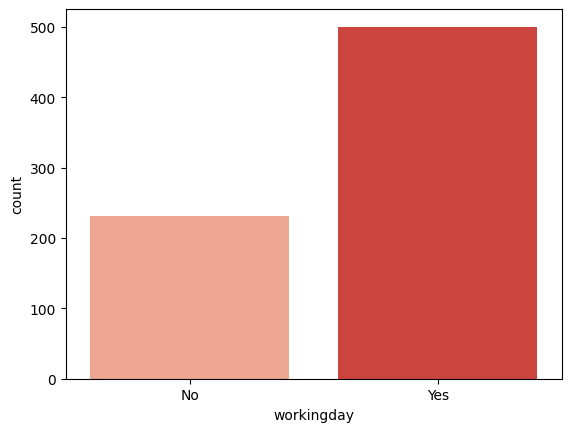

In [ ]:
# Distribition of Workdays
sns.countplot(x='workingday', data=dys, palette='Reds').set_xticklabels([MAPPINGS['workingday'][0], MAPPINGS['workingday'][1]])

[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

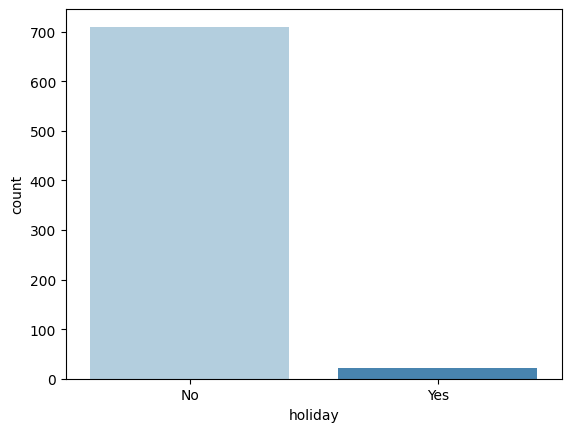

In [ ]:
# Distribition of Holidays
sns.countplot(x='holiday', data=dys, palette='Blues').set_xticklabels([MAPPINGS['holiday'][0], MAPPINGS['holiday'][1]])

[Text(0, 0, 'Clear'),
 Text(1, 0, 'Mist'),
 Text(2, 0, 'Light Rain'),
 Text(3, 0, 'Heavy Rain')]

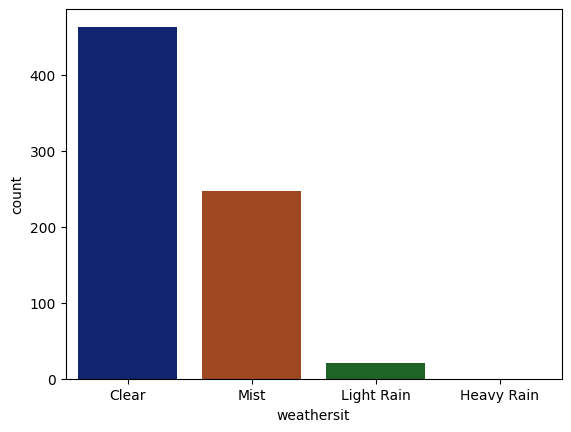

In [ ]:
# Distribition of Weathersit
sns.countplot(x='weathersit', data=dys, palette='dark', order=[1, 2, 3, 4]).set_xticklabels([MAPPINGS['weathersit'][i] for i in [1, 2, 3, 4]])

* We won't spend much time on univariate analysis because the insights won't be very meaningful, We'll focus more on relationships with the target (casual/registered/cnt)

## Target Analysis

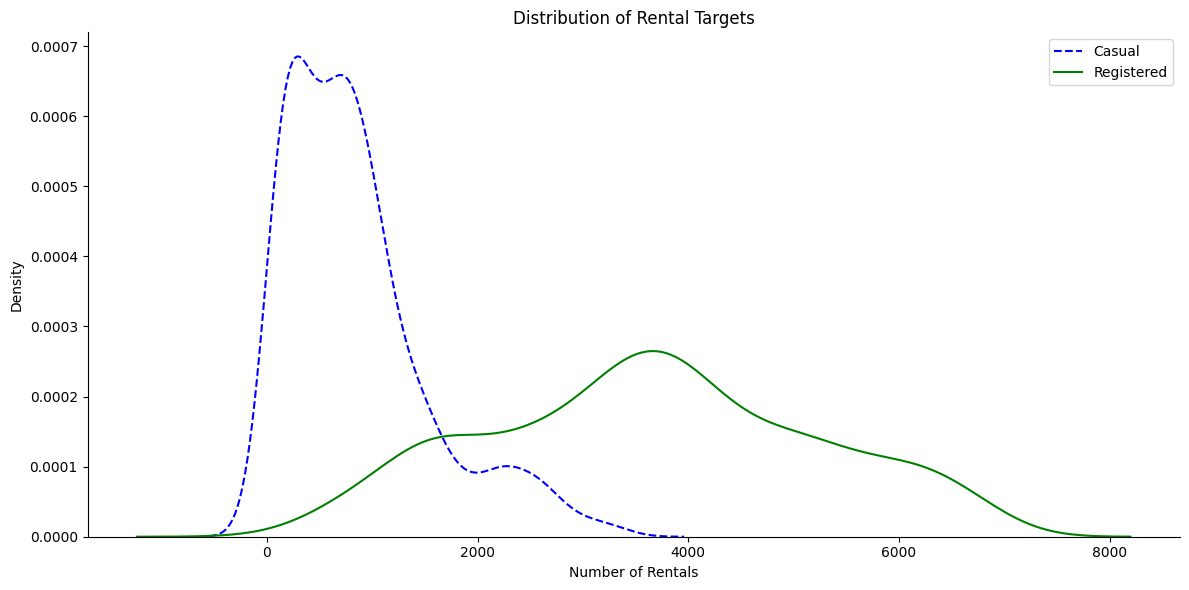

In [ ]:
# Target Distribution Analysis
plt.figure(figsize=(12, 6))

# Plot distribution of each target variable
sns.kdeplot(data=dys['casual'], label='Casual', color='blue', linestyle='--')
sns.kdeplot(data=dys['registered'], label='Registered', color='green', linestyle='-')

plt.title('Distribution of Rental Targets')
plt.xlabel('Number of Rentals')
plt.ylabel('Density')
plt.legend()
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Casual Count vs Registered Count
casual_count= dys["casual"].sum()
registered_count = dys["registered"].sum()

print(f"Total Casual Rentals: {casual_count}")
print(f"Total Registered Rentals: {registered_count}")

Total Casual Rentals: 620017
Total Registered Rentals: 2672662


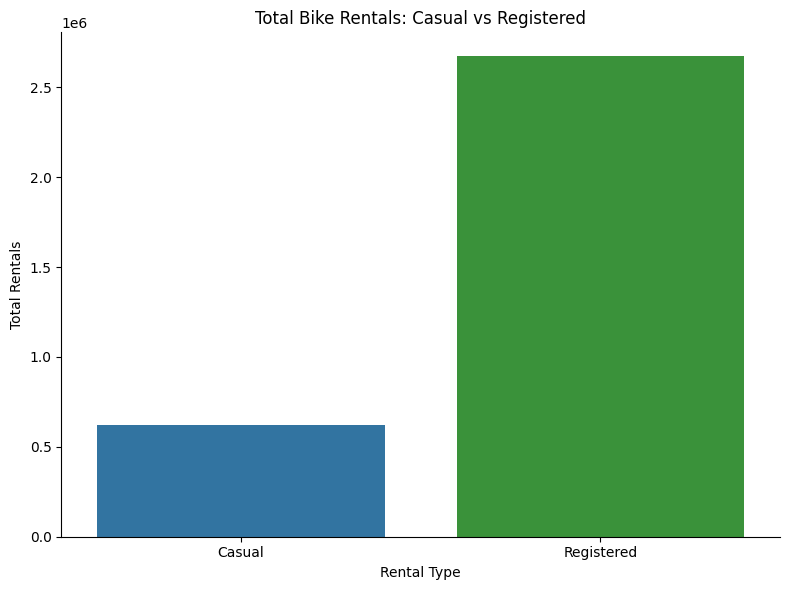

In [ ]:
# Create a DataFrame for plotting
count_data = pd.DataFrame({
    'Rental Type': ['Casual', 'Registered'],
    'Count': [casual_count, registered_count]})

# Create the bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=count_data,x='Rental Type', y='Count', palette=['#1f77b4', '#2ca02c'])

plt.title('Total Bike Rentals: Casual vs Registered')
plt.ylabel('Total Rentals')
sns.despine()
plt.tight_layout()
plt.show()

## Features With Targets

Some Functions to Help us in Visualizition

In [ ]:
def plot_hist_px(data, x , y , color):
    """
    Plots bike rental demand by Features (season, mnth, eg...)

    Parameters:
    data (DataFrame): Input data containing 'season' and 'cnt' columns
    x: Column for x-axis
    y: Column for y-axis
    color: Column for color grouping (using it like hue)
    """
    fig = px.histogram(data,
             x=x,
             y=y,
             title=f'Bike Rental Demand by {x}',
             template='plotly_white',
             labels={'cnt': 'Total Rentals', x: x },
             color=x,
             color_discrete_sequence=px.colors.qualitative.Pastel)

    fig.update_layout(
        bargap=0.2,
        xaxis=dict(
            showgrid=False,
            tickvals=list(MAPPINGS[x].keys()),
            ticktext=list(MAPPINGS[x].values())),
        yaxis=dict(showgrid=False)
    )

    return fig

In [ ]:
def plot_line_px(data, x , y):
    """
    Plots bike rental demand by Features (season, mnth, eg...)

    Parameters:
    data (DataFrame): Input data containing 'season' and 'cnt' columns
    x: Column for x-axis
    y: Column for y-axis
    color: Column for color grouping (using it like hue)
    """
    fig = px.line(data,
             x=x,
             y=y,
             title=f'Temporal Distribution for {x} of Bike Rentals (2011-2012)',
             template='plotly_white',
             labels={'cnt': 'Total Rentals', x: x },
             color_discrete_sequence=px.colors.qualitative.Pastel)

    fig.update_layout(
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False)
    )
    return fig

In [ ]:
def plot_hist_sns(data, x , hue , bins=50, palette='dark'):
    """
    Plots rental distribution with automatic mapping of hue labels

    Parameters:
    data: DataFrame containing the data
    x: Column for x-axis
    hue : Column for color grouping
    """
    plt.figure(figsize=(20, 8))
    sns.histplot(data=data,
                 x=x,
                 hue=hue,
                 bins=bins,
                 kde=True,
                 palette=palette
                 ).set_xticklabels([MAPPINGS['workingday'][0], MAPPINGS['workingday'][1]])

    plt.title(f'Rental Count Distribution by {hue.capitalize()} Status')
    plt.xlabel('Total Rentals')
    plt.show()

In [ ]:
# Daily cnt Bike Rental Demand: 2011-2012
plot_line_px(hrs, 'dteday', 'cnt')

In [ ]:
# Daily registered & casual Bike Rental Demand: 2011-2012
plot_line_px(hrs, 'dteday', ['registered', 'casual'])

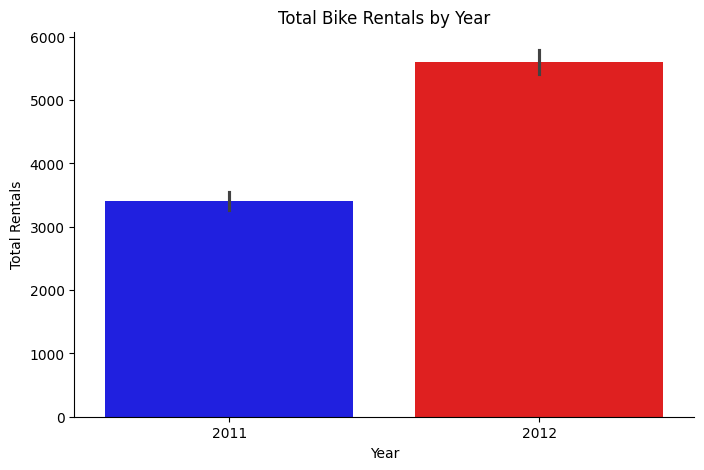

In [ ]:
# Distribution for years of Bike Rentals (2011-2012)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='yr', y='cnt', data=dys, palette=['blue', 'red'])

ax.set_xticklabels([MAPPINGS['yr'][0], MAPPINGS['yr'][1]])
plt.title('Total Bike Rentals by Year')
plt.xlabel('Year')
plt.ylabel('Total Rentals')
sns.despine()
plt.show()

In [ ]:
# Temporal Distribution for Seasons of Bike Rentals For 'cnt' (2011-2012)
plot_hist_px(dys, 'season', 'cnt', 'season')

In [ ]:
# Temporal Distribution for Months of Bike Rentals For 'cnt' (2011-2012)
plot_hist_px(dys, 'mnth', 'cnt', 'mnth')

In [ ]:
# Temporal Distribution for Weekdays of Bike Rentals For 'cnt' (2011-2012)
plot_hist_px(dys, 'weekday', 'cnt', 'weekday')

In [ ]:
# Temporal Distribution for Hours of Bike Rentals For 'cnt' (2011-2012)
plot_hist_px(hrs, 'hr', 'cnt', 'hr')

In [ ]:
# Temporal Distribution for Seasons of Bike Rentals For both of 'registered', 'casual' (2011-2012)
hours = hrs.groupby('hr').agg({
    'registered': 'sum',
    'casual': 'sum',
    'cnt': 'sum'
}).reset_index()

# Daily registered & casual Bike Rental Demand: 2011-2012
plot_line_px(hours, 'hr', ['registered', 'casual'])

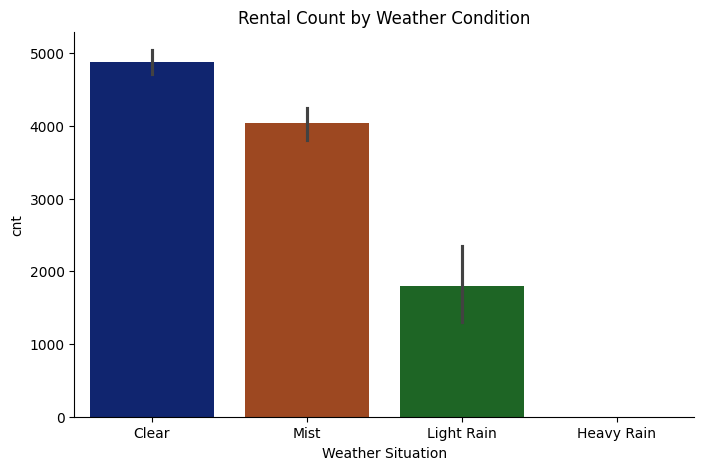

In [ ]:
# Distribition of Weathersit for Bike Rentals For 'cnt' (2011-2012)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='weathersit',
                 y='cnt',
                 data=dys,
                 palette='dark',
                 order=[1, 2, 3, 4])

ax.set_xticklabels([MAPPINGS['weathersit'][i] for i in [1, 2, 3, 4]])
plt.title('Rental Count by Weather Condition')
plt.xlabel('Weather Situation')
sns.despine()
plt.show()

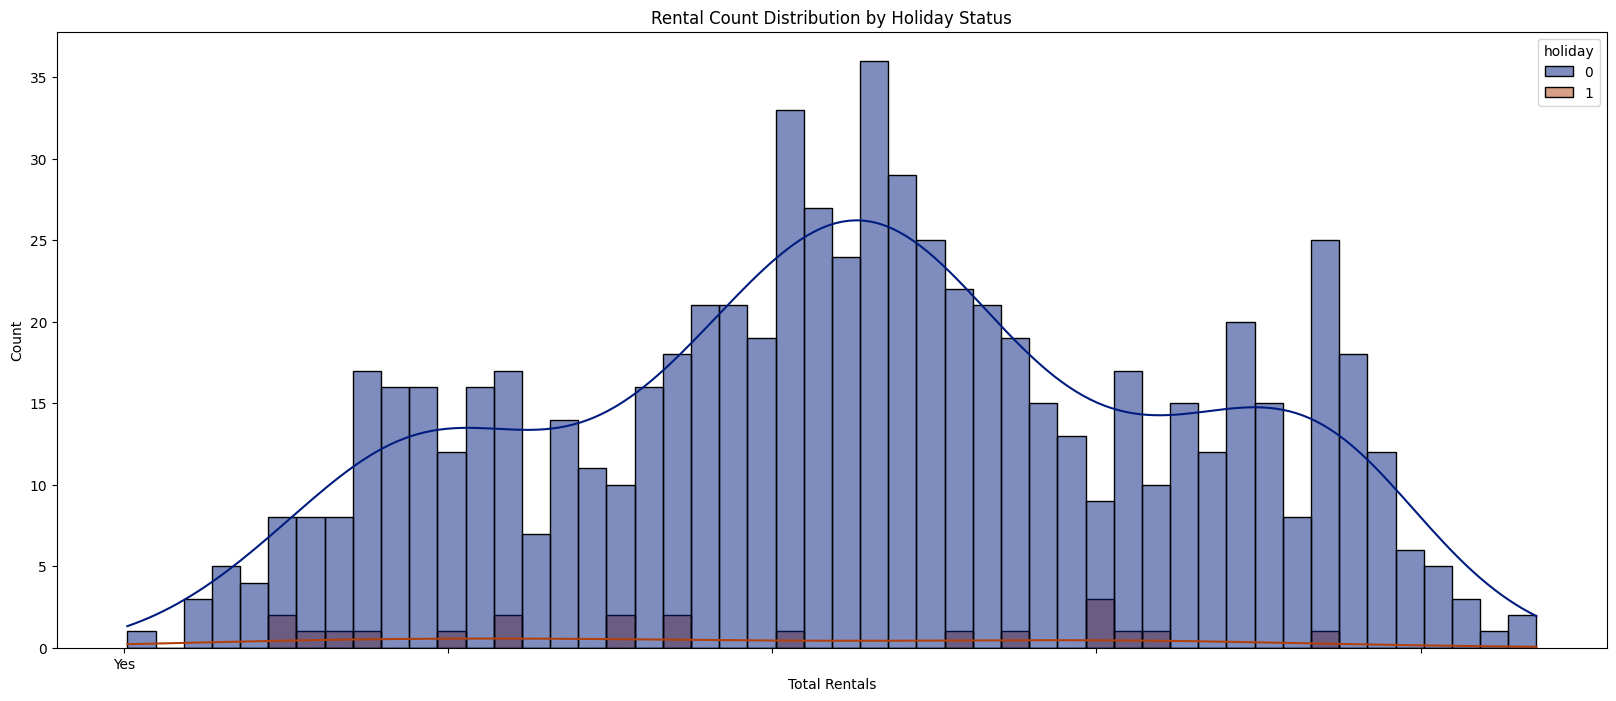

In [ ]:
# Distribition ofBike Rentals For 'cnt' by 'Holidays'
plot_hist_sns(dys, 'cnt' , 'holiday')

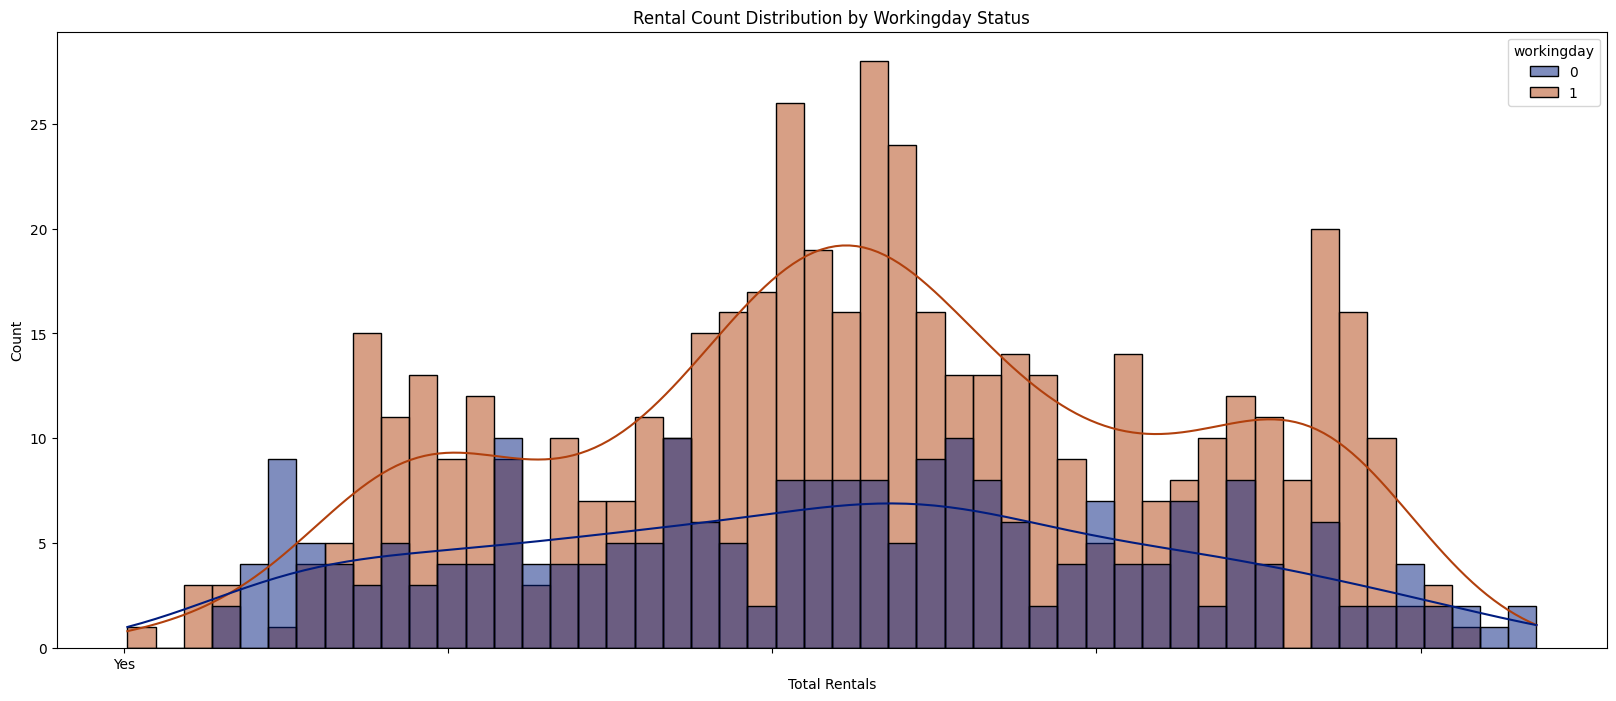

In [ ]:
# Distribition ofBike Rentals For 'cnt' by 'workingday'
plot_hist_sns(dys, 'cnt' , 'workingday')

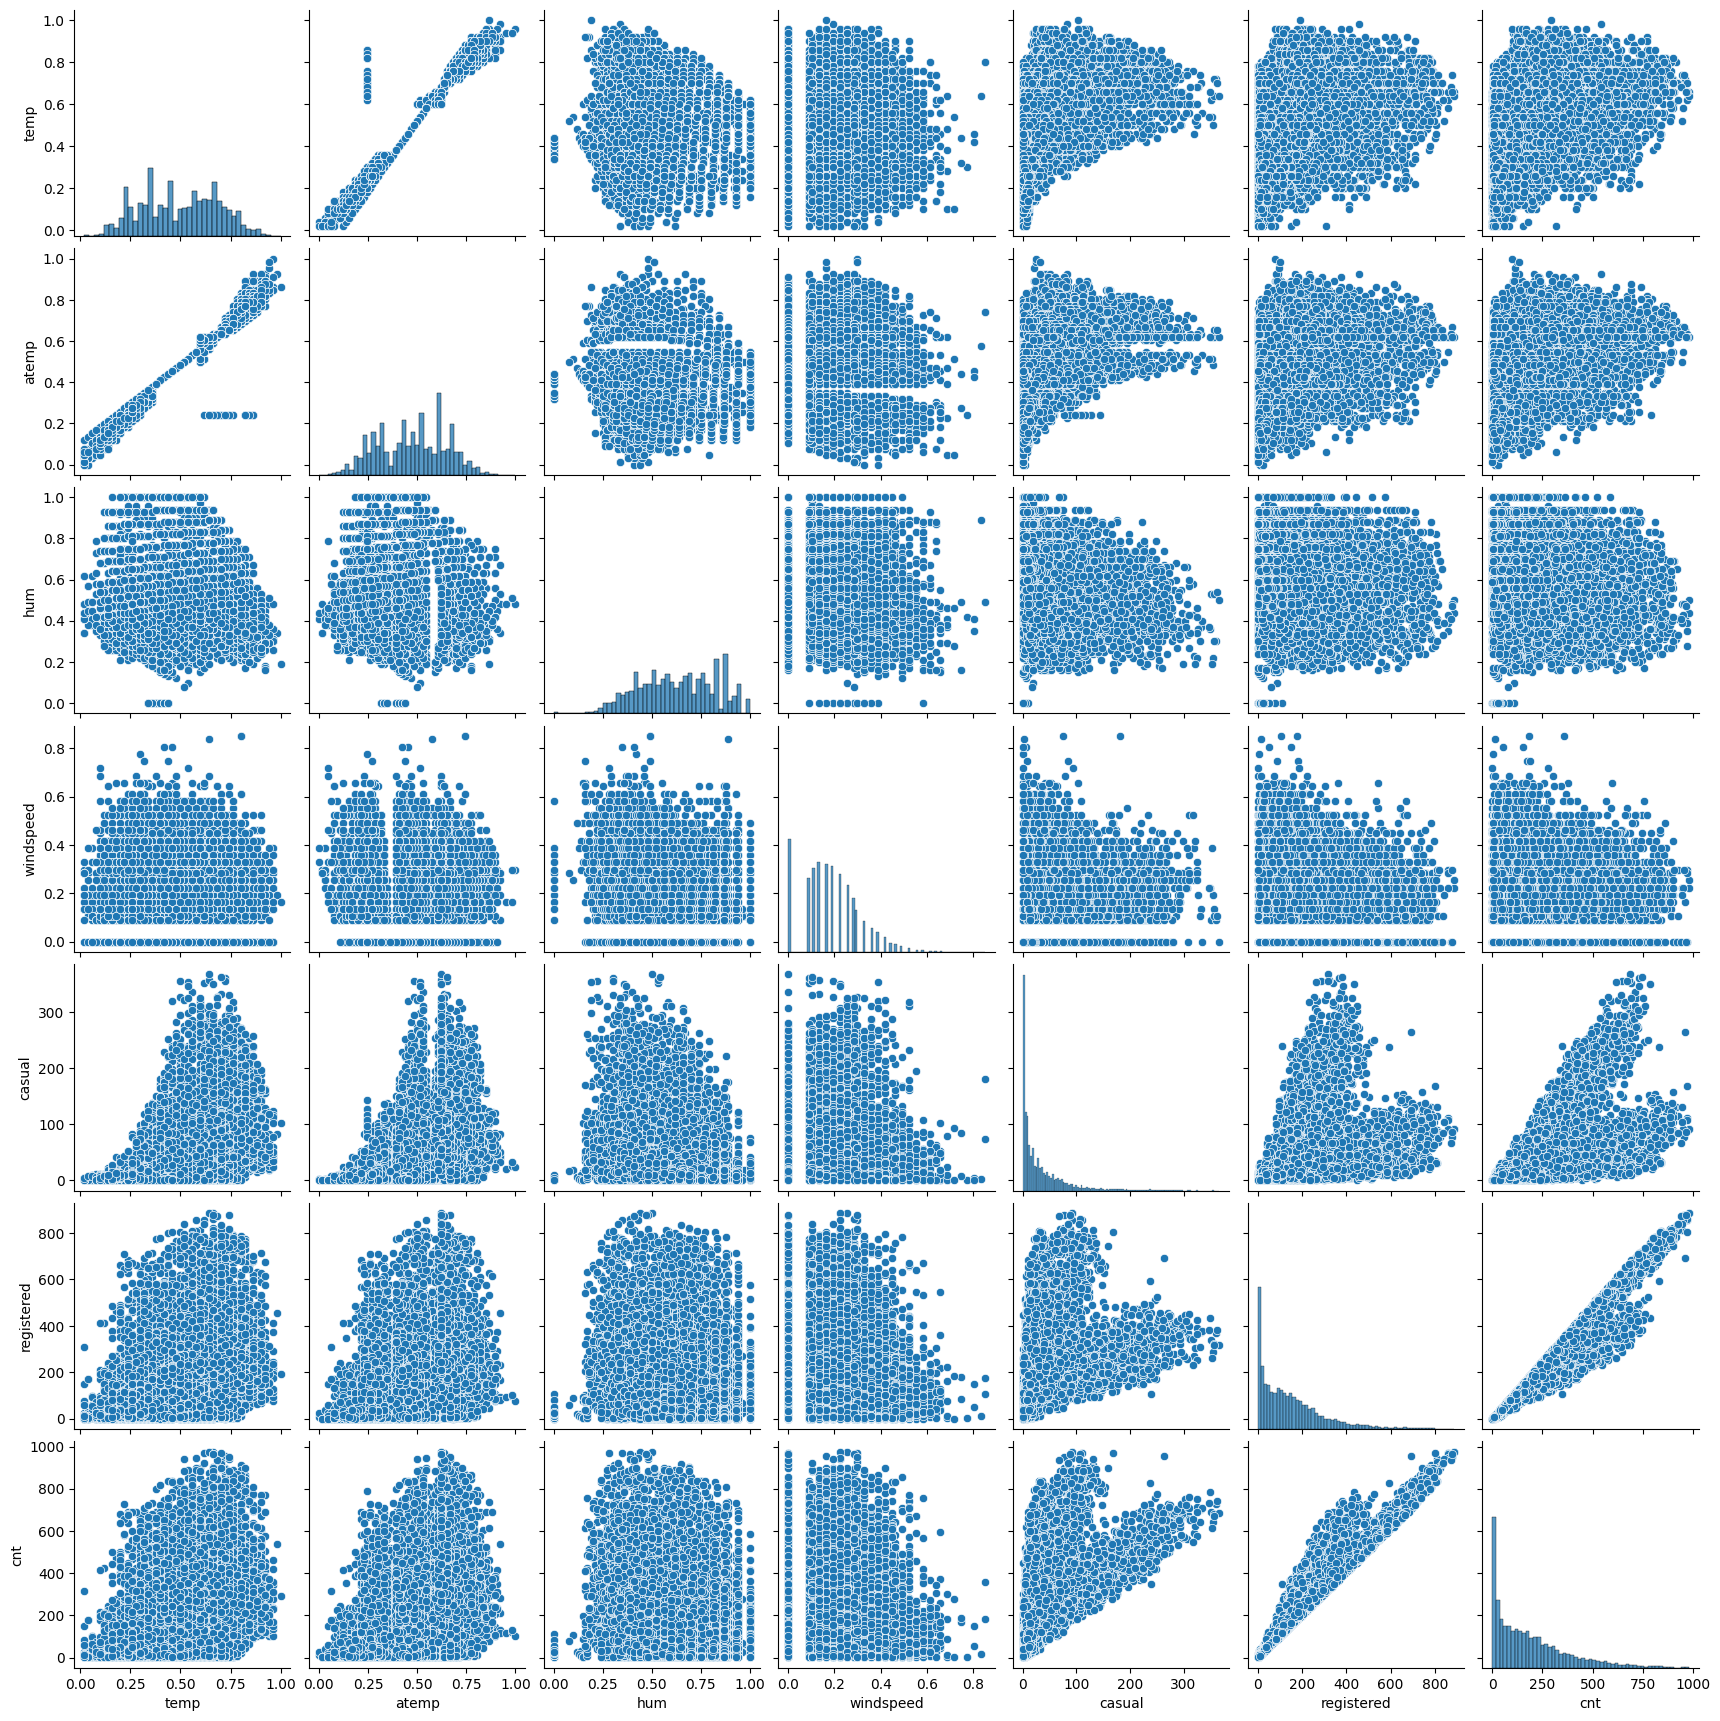

In [ ]:
# Select the Numeric columns to analyze
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

sns.pairplot(hrs[num_cols])
plt.show()

### Correlition with Targets

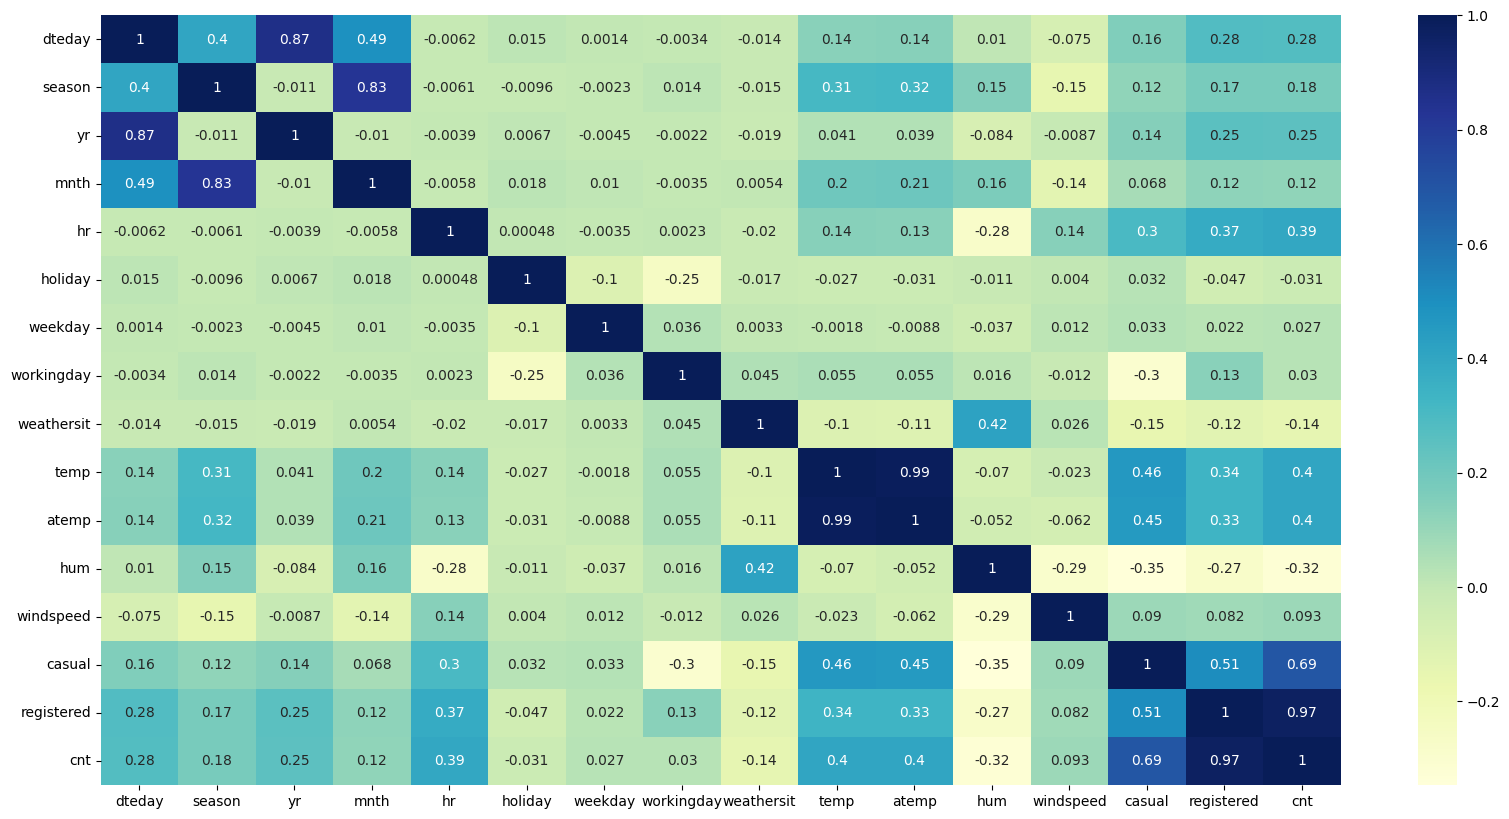

In [ ]:
# All Features Correlitiom
corr = hrs.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.show()

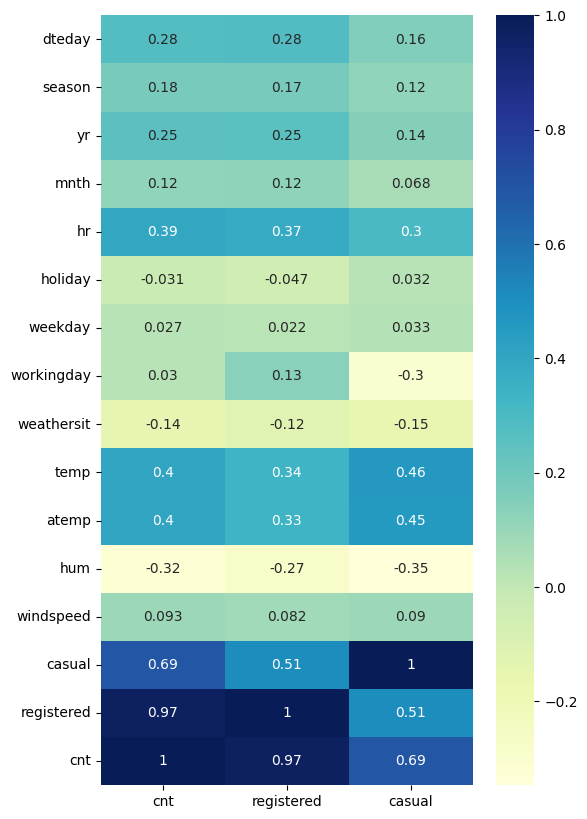

In [ ]:
# All Features Corr With Target
c = hrs.corr()[['cnt', 'registered', 'casual']]
plt.figure(figsize=(6, 10))
sns.heatmap(c, annot=True, cmap='YlGnBu')
plt.show()

## Insights

### Business Insights from Bike Rental Analysis  
```
1. User Segmentation:  
   - Casual Users: Rentals range between 0-1,300.  
   - Registered Users: Rentals range significantly higher, between 2,000-5,000.  

2. Rental Volume Comparison:  
   - Registered users dominate with 2,672,662 rentals, accounting for 4 times the rentals of casual users.  

3. Yearly Growth:  
   - 2012 showed an increase in total rentals compared to 2011, indicating positive growth.  

4. Seasonal Trends:  
   - Peak rental activity occurs during summer and fall (May to October).  

5. Weekday Analysis:  
   - No significant variation in rentals across weekdays; demand remains consistent.  

6. Hourly Patterns:  
   - Registered Users: Peak rentals at 8 AM and 4–7 PM (likely commute-related).  
   - Casual Users: Highest activity between 10 AM–7 PM, with no distinct peak hour.  

7. Weather Impact:  
   - Most rentals occur during clear or misty weather.  
   - Note: These conditions dominated the 2-year dataset, potentially skewing observations.  

8. Holidays/Weekends:  
   - Contrary to expectations, rentals during holidays and weekends did not show a marked difference compared to regular days.  
```
**Some Recommendations Based on Insights:**  

1. **Target Casual Users**  
   - Offer discounts/loyalty programs to convert them to registered users.  

2. **Boost Summer/Fall Demand**  
   - Increase bike availability + launch seasonal promotions.  

3. **Optimize Peak Hour Availability**  
   - Prioritize bike distribution near business areas during rush hours (8 AM & 4–7 PM).  

4. **Weather-Based Strategies**  
   - Rain-day discounts to encourage rentals.  


---  🚲📈  


### Correlation Insights & Steps For Modeling
```
- The Most of Features have a Corr with Targets
- We Have (temp & atemp) and we Don't need the two because they are highly correlated so we will use only one of them (temp)
- We will Keep All other Features
- We will Drop 'cnt' column from the dataset and Now our target is to predict two outputs 'casual' and 'registered' columns
- We will Apply quick classic ml models for Tha 2 Dataets
- We will Apply Deep Learning model for Tha 2 Dataets

```

# Data Splitting & Preprocessing

In [ ]:
# Drop 'cnt', 'temp'
hrs.drop(['cnt', 'atemp', 'dteday'], axis=1, inplace=True)
dys.drop(['cnt', 'atemp', 'dteday'], axis=1, inplace=True)

# Quick look of data before working
hrs.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered
0,1,0,1,0,0,6,0,1,0.24,0.81,0.0,3,13
1,1,0,1,1,0,6,0,1,0.22,0.80,0.0,8,32
2,1,0,1,2,0,6,0,1,0.22,0.80,0.0,5,27
3,1,0,1,3,0,6,0,1,0.24,0.75,0.0,3,10
4,1,0,1,4,0,6,0,1,0.24,0.75,0.0,0,1


*Since the Days dataset is relatively small (500 rows), we'll use it for normal prediction (with basic features). For the larger Hours dataset (15K rows), we'll leverage time-series forecasting to capture temporal patterns.*

```
Time-Series Preparation for Hours Dataset:
1. Date Sorting: Critical for valid time-series splits and to prevent
   leakage of future information into past training data
2. Stationarity Test: We'll test both original and differenced (stationary)
   versions to compare model performance
```

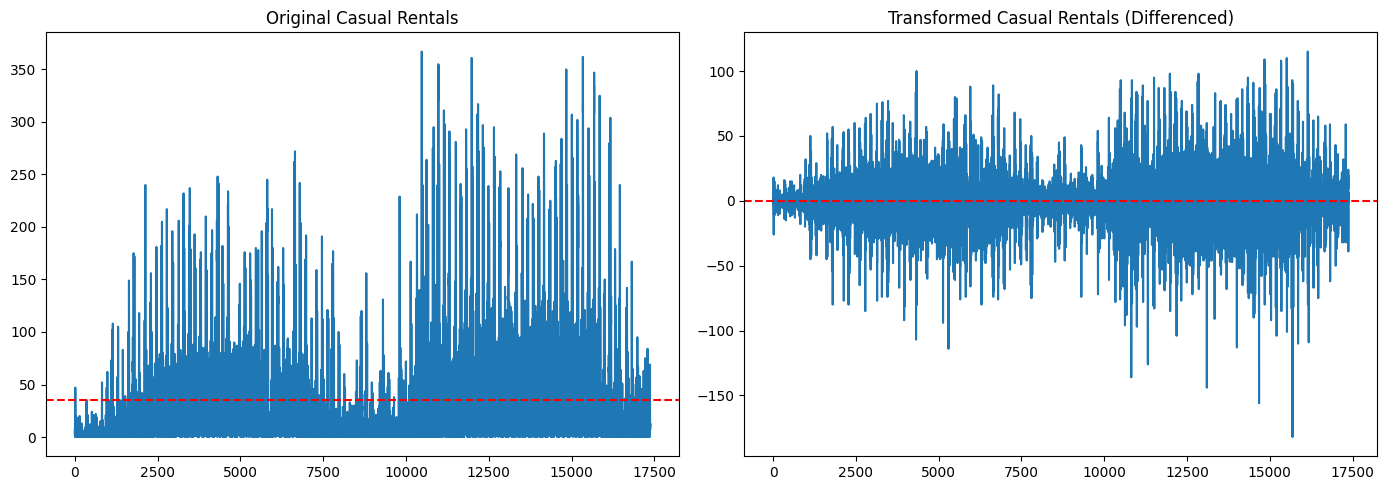

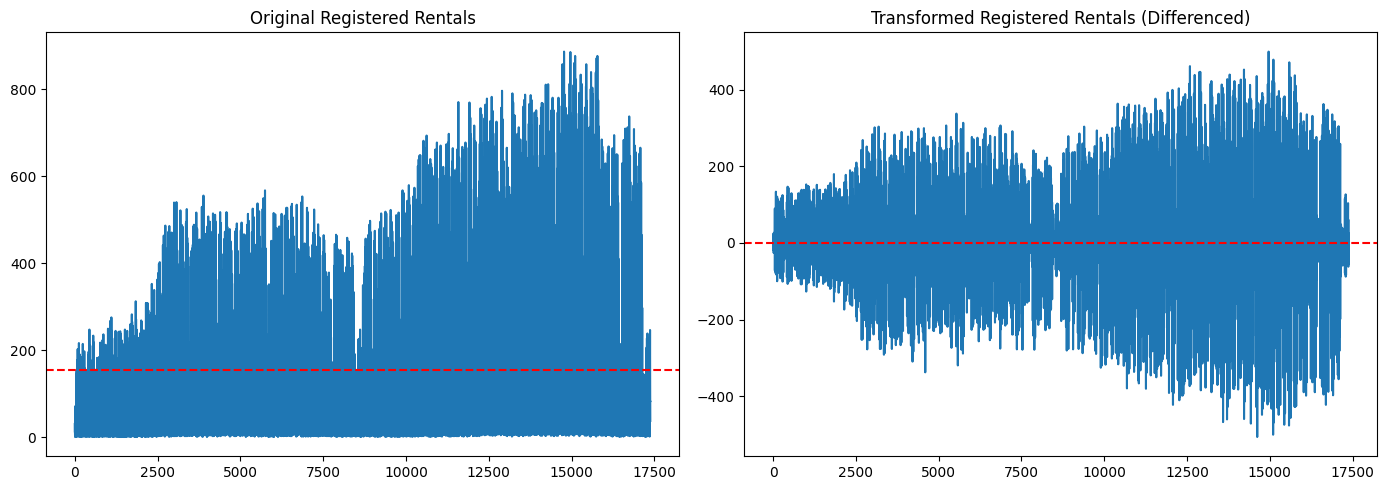


Statistical Analysis:

CASUAL Statistics:
Original - Mean: 35.68, Std: 49.31
Transformed - Mean: 0.00, Std: 17.37
Stationarity Check (ADF p-value): 0.0000

REGISTERED Statistics:
Original - Mean: 153.79, Std: 151.36
Transformed - Mean: 0.00, Std: 94.95
Stationarity Check (ADF p-value): 0.0000


Final Data Dimensions:
Train: (13902, 11), (13902, 4)
Test: (3476, 11), (3476, 4)


In [ ]:
# from sklearn.model_selection import train_test_split
# from statsmodels.tsa.stattools import adfuller

# # 1. Data Preparation
# xhrs = hrs.drop(['casual', 'registered'], axis=1)
# yhrs = hrs[['casual', 'registered']].copy()

# # 2. Transform the Target to Stationary
# yhrs['casual_diff'] = yhrs['casual'].diff().dropna()
# yhrs['registered_diff'] = yhrs['registered'].diff().dropna()

# # 3. Compare Distribution Before/After Transformation
# def plot_comparison(original, transformed, title):
#     plt.figure(figsize=(14, 5))

#     plt.subplot(1, 2, 1)
#     original.plot(title=f'Original {title}')
#     plt.axhline(y=original.mean(), color='r', linestyle='--')

#     plt.subplot(1, 2, 2)
#     transformed.plot(title=f'Transformed {title} (Differenced)')
#     plt.axhline(y=transformed.mean(), color='r', linestyle='--')

#     plt.tight_layout()
#     plt.show()

# plot_comparison(yhrs['casual'], yhrs['casual_diff'], 'Casual Rentals')
# plot_comparison(yhrs['registered'], yhrs['registered_diff'], 'Registered Rentals')

# # 4. Statistical Analysis
# print("\nStatistical Analysis:")
# print("=====================================")
# for col in ['casual', 'registered']:
#     print(f"\n{col.upper()} Statistics:")
#     print(f"Original - Mean: {yhrs[col].mean():.2f}, Std: {yhrs[col].std():.2f}")
#     print(f"Transformed - Mean: {yhrs[f'{col}_diff'].mean():.2f}, Std: {yhrs[f'{col}_diff'].std():.2f}")
#     print(f"Stationarity Check (ADF p-value): {adfuller(yhrs[f'{col}_diff'].dropna())[1]:.4f}")

# # 5. Split the Data (as in your original code)
# yhrs_clean = yhrs.dropna()
# xhrs_clean = xhrs.loc[yhrs_clean.index]

# xh_train, xh_test, yh_train, yh_test = train_test_split(xhrs_clean,yhrs_clean,test_size=0.2,shuffle=False)

# print("\n\nFinal Data Dimensions:")
# print("=====================================")
# print(f"Train: {xh_train.shape}, {yh_train.shape}")
# print(f"Test: {xh_test.shape}, {yh_test.shape}")

* The data is already sorted, so no need to shuffle
* `After testing multiple models with Stationary Target, differencing didn't improve Performance — we'll proceed without it`


In [ ]:
# Split into train and test
from sklearn.model_selection import train_test_split

xdys = dys.drop(['casual', 'registered'], axis=1)
xhrs = hrs.drop(['casual', 'registered'], axis=1)

ydys = dys[['casual', 'registered']]
yhrs = hrs[['casual', 'registered']]

# days dataset split
xd_train, xd_test, yd_train, yd_test = train_test_split(xdys, ydys, test_size=0.2, random_state=42)

# hours dataset split
xh_train, xh_test, yh_train, yh_test = train_test_split(xhrs, yhrs, test_size=0.2, shuffle=False) # Shuffle=False to keep the order of datetime

* As we say Above There are many Features numeric but we should consider them Cat For Model Training

In [ ]:
# Preprocessing Libraries Needed
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numerical columns
num_cols = ['temp', 'hum', 'windspeed'] # All are normalized

# Categorical columns
cat_cols_h = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit'] # To be one-hot encoded
cat_cols_d = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

# Create separate transformers
preprocessor_d = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=True, handle_unknown='ignore'), cat_cols_d),
    ('num', 'passthrough', num_cols) # Because All are normalized
])

preprocessor_h = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=True, handle_unknown='ignore'), cat_cols_h),
    ('num', 'passthrough', num_cols)
])

# Apply quick classic ml models

**We need to declare 2 Functions**

- Model Tunning
- Model Evaluation

We will Walk With this structure
1. We will try 4-5 Classic Ml Models Then Try To Build A Neural Network
2. Tring Each Model on The two Datasets without any thing
3. apply The Model tunning Func on Each Model to Know the best Params
4. Apply The Model Evaluation func on Each Model To know The Best We got it

In [ ]:
# Import Libraries For Modeling
from sklearn.model_selection import GridSearchCV ,cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
def model_tuning(model, x, y, params):
    '''
    Parameters:
        1. model: the model we want to tune.
        2. x: feature matrix.
        3. y: target vector.
        4. params: hyperparameters we want to tune.

    Returns:
        best model: the model with the best hyperparameters after tuning.
    '''

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring='r2')

    grid_search.fit(x, y)  # fit the model to the data
    print(f"Best parameters: {grid_search.best_params_}")  # print the best hyperparameters
    print(f"Best score (R^2): {grid_search.best_score_:.2f}")  # print the best R^2 score

    return grid_search.best_estimator_

In [ ]:
def model_evaluation(model, x, y, n , Dataset_name):

    '''This function validates the model across multiple stratified splits using cross-validation'''

    # Perform cross-validation
    scores = cross_val_score(model, x, y, scoring='r2', cv=n)

    # Calculate the mean score and standard deviation across all folds
    print(f'R^2 Score (mean) for {Dataset_name}: {scores.mean():.2f}')
    print(f'R^2 Score (std) for {Dataset_name}: {scores.std():.2f}')

    # Calculate accuracy
    print(f"Accuracy for {Dataset_name}: {model.score(x,y):.2f} %")

    # Make predictions to calculate RMSE
    y_pred = model.predict(x)

    # Calculate and print RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    print(f'RMSE for {Dataset_name}: {rmse:.2f}')

## Linear Regression

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression

# Full Pipeline (Preprocessor With Model) For Two Datasets
lr_d = make_pipeline(preprocessor_d,
                   LinearRegression())

lr_h = make_pipeline(preprocessor_h,
                   LinearRegression())

# Fitting The Model on Two Datasets
lr_d.fit(xd_train, yd_train)
lr_h.fit(xh_train, yh_train)

# See What We Got Without Tunning or anything
print("Train score for Days: ", lr_d.score(xd_train, yd_train))
print("Train score for Hours: ", lr_h.score(xh_train, yh_train))

Train score for Days:  0.8005881986158686
Train score for Hours:  0.6359018898881216


**Tunning**

In [ ]:
# Full Pipeline (Preprocessor With Model & Poly Features) For Two Datasets
poly_d = make_pipeline(preprocessor_d,
                          PolynomialFeatures(),
                          LinearRegression())

poly_h = make_pipeline(preprocessor_h,
                          PolynomialFeatures(),
                          LinearRegression())

# Params For Model Tuning
params = {'polynomialfeatures__degree': [1, 2]} # We will Try 2 Degrees only Because It Take a Looooooong Time

# Model Tuning for Days Dataset
final_model_d = model_tuning(poly_d, xd_train, yd_train, params)

# Model Tuning for Hours Dataset
final_model_h = model_tuning(poly_h, xh_train, yh_train, params)

Best parameters: {'polynomialfeatures__degree': 1}
Best score (R^2): 0.76
Best parameters: {'polynomialfeatures__degree': 2}
Best score (R^2): 0.53


In [ ]:
# Evaluation the Model for Days Dataset
model_evaluation(final_model_d,xd_train, yd_train,5 , 'Days')

R^2 Score (mean) for Days: 0.76
R^2 Score (std) for Days: 0.04
Accuracy for Days: 0.80 %
RMSE for Days: 484.35


In [ ]:
# Evaluation the Model for Hours Dataset
model_evaluation(final_model_h,xh_train, yh_train,5 , 'Hours')

R^2 Score (mean) for Hours: 0.53
R^2 Score (std) for Hours: 0.27
Accuracy for Hours: 0.90 %
RMSE for Hours: 28.38


## SVR

In [ ]:
# Support Vector Regressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

# Full Pipeline (Preprocessor With Model) For Two Datasets
svr_d = make_pipeline(preprocessor_d,
                      MultiOutputRegressor(SVR(kernel='linear')))

svr_h = make_pipeline(preprocessor_h,
                      MultiOutputRegressor(SVR(kernel='linear')))

# Fitting The Model on Two Datasets
svr_d.fit(xd_train, yd_train)
svr_h.fit(xh_train, yh_train)

# See What We Got Without Tunning or anything
print("Train score for Days: ", svr_d.score(xd_train, yd_train))
print("Train score for Hours: ", svr_h.score(xh_train, yh_train))

Train score for Days:  0.2364162680485422
Train score for Hours:  0.5412430054331174


**Tunning**

In [ ]:
#Define The SVR Model with kernels poly or rbf
svr_d = make_pipeline(preprocessor_d,
                      MultiOutputRegressor(SVR()))

svr_h = make_pipeline(preprocessor_h,
                      MultiOutputRegressor(SVR()))

# Paramaters for svr model
params = {
    'multioutputregressor__estimator__C': [0.1, 1, 10],
    'multioutputregressor__estimator__kernel': ['linear', 'rbf'],
    'multioutputregressor__estimator__gamma': ['scale', 'auto']}

# Model Tuning for Days Dataset
final_svr_d = model_tuning(svr_d, xd_train, yd_train, params)

# Model Tuning for Hours Dataset
final_svr_h = model_tuning(svr_h, xh_train, yh_train, params)

Best parameters: {'multioutputregressor__estimator__C': 10, 'multioutputregressor__estimator__gamma': 'scale', 'multioutputregressor__estimator__kernel': 'linear'}
Best score (R^2): -0.17
Best parameters: {'multioutputregressor__estimator__C': 10, 'multioutputregressor__estimator__gamma': 'scale', 'multioutputregressor__estimator__kernel': 'rbf'}
Best score (R^2): 0.64


In [ ]:
# Evaluation the Model for Days Dataset
model_evaluation(final_svr_d, xd_train, yd_train,5 , 'Days')

R^2 Score (mean) for Days: -0.17
R^2 Score (std) for Days: 0.92
Accuracy for Days: 0.69 %
RMSE for Days: 559.87


In [ ]:
# Evaluation the Model for Hours Dataset
model_evaluation(final_svr_h, xh_train, yh_train,5 , 'Hours')

R^2 Score (mean) for Hours: 0.64
R^2 Score (std) for Hours: 0.06
Accuracy for Hours: 0.79 %
RMSE for Hours: 45.56


## Decision Tree Regressor

In [ ]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Full Pipeline (Preprocessor With Model) For Two Datasets
tree_d = make_pipeline(preprocessor_d,
                         DecisionTreeRegressor())

tree_h = make_pipeline(preprocessor_h,
                         DecisionTreeRegressor())

# Fitting The Model on Two Datasets
tree_d.fit(xd_train, yd_train)
tree_h.fit(xh_train, yh_train)

# See What We Got Without Tunning or anything
print("Train score for Days: ", tree_d.score(xd_train, yd_train))
print("Train score for Hours: ", tree_h.score(xh_train, yh_train))

Train score for Days:  1.0
Train score for Hours:  0.9999838314069003


In [ ]:
# Parameters for forest Regressor
params = {
    'decisiontreeregressor__max_depth': [3, 5, 7, 10, None],
    'decisiontreeregressor__min_samples_split': [2, 5, 10, 20],
    'decisiontreeregressor__min_samples_leaf': [1, 2, 4, 8],
    'decisiontreeregressor__max_features': ['auto', 'sqrt', 'log2', 0.8]
}

# Model Tuning for Days Dataset
final_tree_d = model_tuning(tree_d, xd_train, yd_train, params)

# Model Tuning for Hours Dataset
final_tree_h = model_tuning(tree_h, xh_train, yh_train, params)

Best parameters: {'decisiontreeregressor__max_depth': 10, 'decisiontreeregressor__max_features': 0.8, 'decisiontreeregressor__min_samples_leaf': 8, 'decisiontreeregressor__min_samples_split': 10}
Best score (R^2): 0.77
Best parameters: {'decisiontreeregressor__max_depth': None, 'decisiontreeregressor__max_features': 0.8, 'decisiontreeregressor__min_samples_leaf': 4, 'decisiontreeregressor__min_samples_split': 20}
Best score (R^2): 0.57


In [ ]:
# Evaluation the Model for Days Dataset
model_evaluation(final_tree_d, xd_train, yd_train, 5 , 'Days')

R^2 Score (mean) for Days: 0.75
R^2 Score (std) for Days: 0.04
Accuracy for Days: 0.85 %
RMSE for Days: 426.09


In [ ]:
# Evaluation the Model for Hours Dataset
model_evaluation(final_tree_h, xh_train, yh_train,5 , 'Hours')

R^2 Score (mean) for Hours: 0.52
R^2 Score (std) for Hours: 0.13
Accuracy for Hours: 0.90 %
RMSE for Hours: 27.21


## Random Forest Regressor

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Full Pipeline (Preprocessor With Model) For Two Datasets
forest_d = make_pipeline(preprocessor_d,
                         RandomForestRegressor())

forest_h = make_pipeline(preprocessor_h,
                         RandomForestRegressor())

# Fitting The Model on Two Datasets
forest_d.fit(xd_train, yd_train)
forest_h.fit(xh_train, yh_train)

# See What We Got Without Tunning or anything
print("Train score for Days: ", forest_d.score(xd_train, yd_train))
print("Train score for Hours: ", forest_h.score(xh_train, yh_train))

Train score for Days:  0.9763949709790336
Train score for Hours:  0.986162974923352


**Tunning**

In [ ]:
# Parameters for forest Regressor
params = {
    'randomforestregressor__n_estimators': [50, 100],
    'randomforestregressor__max_depth': [None, 5, 10],
    'randomforestregressor__min_samples_split': [2, 5]
}

# Model Tuning for Days Dataset
final_forest_d = model_tuning(forest_d, xd_train, yd_train, params)

# Model Tuning for Hours Dataset
final_forest_h = model_tuning(forest_h, xh_train, yh_train, params)

Best parameters: {'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 50}
Best score (R^2): 0.82
Best parameters: {'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100}
Best score (R^2): 0.71


In [ ]:
# Evaluation the Model for Days Dataset
model_evaluation(final_forest_d, xd_train, yd_train,5 , 'Days')

R^2 Score (mean) for Days: 0.82
R^2 Score (std) for Days: 0.04
Accuracy for Days: 0.98 %
RMSE for Days: 177.47


In [ ]:
# Evaluation the Model for Hours Dataset
model_evaluation(final_forest_h, xh_train, yh_train,5 , 'Hours')

R^2 Score (mean) for Hours: 0.71
R^2 Score (std) for Hours: 0.13
Accuracy for Hours: 0.99 %
RMSE for Hours: 10.38


## XGB Regressor

In [ ]:
# XGBoost Regressor
from xgboost import XGBRegressor

# Initialize the XGBoost Regressor
xgb_d = make_pipeline(preprocessor_d,
                      XGBRegressor(random_state=42))

xgb_h = make_pipeline(preprocessor_h,
                      XGBRegressor(random_state=42))

# Fitting The Model on Two Datasets
xgb_d.fit(xd_train, yd_train)
xgb_h.fit(xh_train, yh_train)

# See What We Got Without Tunning or anything
print("Train score for Days: ", xgb_d.score(xd_train, yd_train))
print("Train score for Hours: ", xgb_h.score(xh_train, yh_train))

Train score for Days:  0.9999087452888489
Train score for Hours:  0.9662277698516846


In [ ]:
# Parameters for xgb Regressor
params = {
    'xgbregressor__n_estimators': [50, 100 , 200],
    'xgbregressor__max_depth': [3 ,5, 7],
    'xgbregressor__learning_rate': [0.01 ,0.1, 0.2],
    'xgbregressor__reg_alpha': [0, 0.1, 1],  # L1 Regularization
    'xgbregressor__reg_lambda': [0, 0.1, 1],  # L2 Regularization
    'xgbregressor__gamma': [0, 0.1, 0.3],     # Minimum Loss Reduction
    'xgbregressor__subsample': [0.8, 1.0],}

# Model Tuning for Days Dataset
final_xgb_d = model_tuning(xgb_d, xd_train, yd_train, params)

# Model Tuning for Hours Dataset
final_xgb_h = model_tuning(xgb_h, xh_train, yh_train, params)

Best parameters: {'xgbregressor__gamma': 0, 'xgbregressor__learning_rate': 0.1, 'xgbregressor__max_depth': 5, 'xgbregressor__n_estimators': 100, 'xgbregressor__reg_alpha': 0.1, 'xgbregressor__reg_lambda': 1, 'xgbregressor__subsample': 0.8}
Best score (R^2): 0.85
Best parameters: {'xgbregressor__gamma': 0.3, 'xgbregressor__learning_rate': 0.1, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 200, 'xgbregressor__reg_alpha': 0.1, 'xgbregressor__reg_lambda': 1, 'xgbregressor__subsample': 0.8}
Best score (R^2): 0.77


In [ ]:
# Evaluation the Model for Days Dataset
model_evaluation(final_xgb_d, xd_train, yd_train,5 , 'Days')

R^2 Score (mean) for Days: 0.85
R^2 Score (std) for Days: 0.04
Accuracy for Days: 0.99 %
RMSE for Days: 119.66


In [ ]:
# Evaluation the Model for Hours Dataset
model_evaluation(final_xgb_h, xh_train, yh_train,5 , 'Hours')

R^2 Score (mean) for Hours: 0.77
R^2 Score (std) for Hours: 0.08
Accuracy for Hours: 0.97 %
RMSE for Hours: 14.79


## ML Conclusion
```
- Best Model We Got For Days Dataset : XGB Regressor With 99% Acc
- Best Model We Got For Hours Dataset : XGB Regressor With 97% Acc
```

# Apply Deep Learning model

*While our current ML model achieves high accuracy on this tabular data,
I'm implementing deep learning for additional practice and comparison,
 despite its likely unnecessary complexity for this use case.*

We need to declare 3 Functions

1. Model Tunning
2. Model Evaluation
3. Model Tunning

We will Follow This Work Steps:
- We will Use Funcs to Build a Model with Neural Network By Using Keras for Using it on Each Dataset
- And We Will evaluate This Model on Each Dataset And see What We Got
- After That We will Tune The Model If Needed

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
# Import Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, Nadam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import keras_tuner as kt
from datetime import datetime
import inspect

In [ ]:
# Preprocessor Fitting
xd_trn = preprocessor_d.fit_transform(xd_train)
xd_tst = preprocessor_d.transform(xd_test)

xh_trn = preprocessor_h.fit_transform(xh_train)
xh_tst = preprocessor_h.transform(xh_test)

In [ ]:
def train_keras_model(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2):
    """
    Trains a basic Keras Sequential regression model

    Parameters:
        X_train (array): Training data features
        y_train (array): Target values
        epochs (int): Number of training iterations (default: 10)
        batch_size (int): Samples per gradient update (default: 32)
        validation_split (float): Fraction of data for validation (default: 0.2)

    Returns:
        history: Training history object containing metrics
    """
    # Initialize model
    model = Sequential()
    model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(2, activation='linear'))
    model.compile(optimizer='adam',
                 loss='mse',
                 metrics=['mse'])

    # Train model and store history
    history = model.fit(X_train,
                       y_train,
                       epochs=epochs,
                       batch_size=batch_size,
                       validation_split=validation_split)

    return history , model

In [ ]:
def evaluate_model(model, X, y):
    """
    Evaluates a Keras model using both built-in evaluation and R² score

    Parameters:
        model: Trained Keras model
        X (array): Input features
        y (array): True target values

    Returns:
        dict: Dictionary containing evaluation metrics
    """
    # Get built-in evaluation metrics
    evaluation = model.evaluate(X, y, verbose=0)

    # Calculate R2 score
    y_pred = model.predict(X, verbose=0)
    r2 = r2_score(y, y_pred)

    return {
        'loss': evaluation[0],
        'mse': evaluation[1],
        'r2_score': r2
    }

In [ ]:
def tune_and_train_model(X_train, y_train,
                        project_name,
                        max_epochs=30,
                        fit_epochs=50,
                        validation_split=0.2,
                        batch_size=64,
                        patience=5,
                        return_dict=False):
    """
    Enhanced version with dynamic variable names and flexible return options

    Args:
        X_train: Input features (accepts any variable name)
        y_train: Target values (accepts any variable name)
        return_dict: If True returns dict, False returns tuple (default)
    """


    # Original build_model function (unchanged)
    def build_model(hp):
        activation = hp.Choice('activation', ['relu', 'elu', 'selu'])
        initializer = hp.Choice('initializer', ['glorot_uniform', 'he_normal'])
        optimizer = hp.Choice('optimizer', ['adam', 'nadam', 'sgd'])
        learning_rate = hp.Float('lr', 1e-4, 1e-2, sampling='log')

        model = Sequential()
        model.add(Dense(
            units=hp.Int('units_1', 64, 256, step=64),
            input_dim=X_train.shape[1],
            activation=activation,
            kernel_initializer=initializer
        ))
        model.add(Dense(
            units=hp.Int('units_2', 32, 128, step=32),
            activation=activation,
            kernel_initializer=initializer
        ))
        model.add(Dense(
            units=hp.Int('units_3', 16, 64, step=16),
            activation=activation,
            kernel_initializer=initializer
        ))
        model.add(Dense(2, activation='linear'))

        if optimizer == 'adam':
            opt = Adam(learning_rate=learning_rate)
        elif optimizer == 'nadam':
            opt = Nadam(learning_rate=learning_rate)
        else:
            opt = SGD(learning_rate=learning_rate, momentum=0.9)

        model.compile(loss='mean_squared_error', optimizer=opt, metrics=['mse'])
        return model

    # Original tuning process (unchanged)
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    tuner = kt.Hyperband(
        build_model,
        objective='val_mse',
        max_epochs=max_epochs,
        factor=3,
        directory='my_dir',
        project_name=project_name,
        overwrite=True,
        max_consecutive_failed_trials=5
    )

    tuner.search(
        X_train,
        y_train,
        epochs=fit_epochs,
        validation_split=validation_split,
        callbacks=[early_stopping],
        batch_size=batch_size
    )

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    model = tuner.hypermodel.build(best_hps)

    history = model.fit(
        X_train,
        y_train,
        epochs=fit_epochs,
        validation_split=validation_split,
        verbose=2,
        callbacks=[early_stopping]
    )

    return model, history, best_hps.values

In [ ]:
# Model For Days Data

# Make The Data Arr before Fitting
xd_trn_arr = xd_trn.toarray()
xd_tst_arr = xd_tst.toarray()

# Train model
history_days , model_days = train_keras_model(xd_trn_arr, yd_train)

# Access training metrics
print(history_days.history.keys())

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 8925068.0000 - mse: 8925068.0000 - val_loss: 7859466.5000 - val_mse: 7859466.5000
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9326166.0000 - mse: 9326166.0000 - val_loss: 7858177.5000 - val_mse: 7858177.5000
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9270910.0000 - mse: 9270910.0000 - val_loss: 7856324.0000 - val_mse: 7856324.0000
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8889186.0000 - mse: 8889186.0000 - val_loss: 7853744.0000 - val_mse: 7853744.0000
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9020522.0000 - mse: 9020522.0000 - val_loss: 7850128.5000 - val_mse: 7850128.5000
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8973126.0000 - mse: 8973126.0000 - val_loss: 7845112.5000 - val_mse: 7845112.5000
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8649163.0000 - mse: 8649163.0000 - val_loss: 7838385.0000 - val_mse: 7838385.0000
Epoch 8/10
15/15 ━━

In [ ]:
# Model For Hours Data

# Make The Data Arr before Fitting
xh_trn_arr = xh_trn.toarray()
xh_tst_arr = xh_tst.toarray()

# Train model
history_hours , model_hours= train_keras_model(xh_trn_arr, yh_train)

# Access training metrics
print(history_hours.history.keys())

Epoch 1/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 15062.5234 - mse: 15062.5234 - val_loss: 23759.9453 - val_mse: 23759.9453
Epoch 2/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7068.4077 - mse: 7068.4077 - val_loss: 16940.9492 - val_mse: 16940.9492
Epoch 3/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5216.4253 - mse: 5216.4253 - val_loss: 11484.9258 - val_mse: 11484.9258
Epoch 4/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3581.1418 - mse: 3581.1418 - val_loss: 9240.0654 - val_mse: 9240.0654
Epoch 5/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2931.6809 - mse: 2931.6809 - val_loss: 8509.0273 - val_mse: 8509.0273
Epoch 6/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2669.3867 - mse: 2669.3867 - val_loss: 8029.2300 - val_mse: 8029.2300
Epoch 7/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2442.1733 - mse: 2442.1733 - val_loss: 7227.3975 - val_mse: 7227.3975
Epoch 8/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2026.4817 - mse: 2026.

In [ ]:
# Evaluate Our Days model
metrics = evaluate_model(model_days, xd_trn_arr, yd_train)

print(f"Model Evaluation Days Data:")
print(f"Loss (MSE): {metrics['loss']:.4f}")
print(f"MSE: {metrics['mse']:.4f}")
print(f"R² Score: {metrics['r2_score']:.4f}")

Model Evaluation Days Data:
Loss (MSE): 8554502.0000
MSE: 8554502.0000
R² Score: -3.6416


In [ ]:
# Evaluate Our Hours model
metrics = evaluate_model(model_hours, xh_trn_arr, yh_train)

print(f"Model Evaluation Hours Data:")
print(f"Loss (MSE): {metrics['loss']:.4f}")
print(f"MSE: {metrics['mse']:.4f}")
print(f"R² Score: {metrics['r2_score']:.4f}")

Model Evaluation Hours Data:
Loss (MSE): 2290.8567
MSE: 2290.8567
R² Score: 0.6287


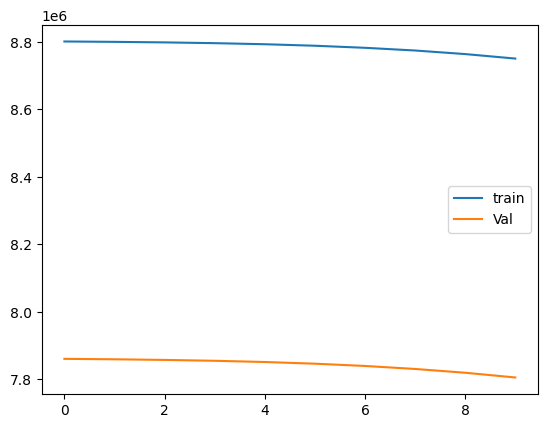

In [ ]:
# plot history for Days Data
plt.plot(history_days.history['loss'], label='train')
plt.plot(history_days.history['val_loss'], label='Val')
plt.legend()
plt.show()

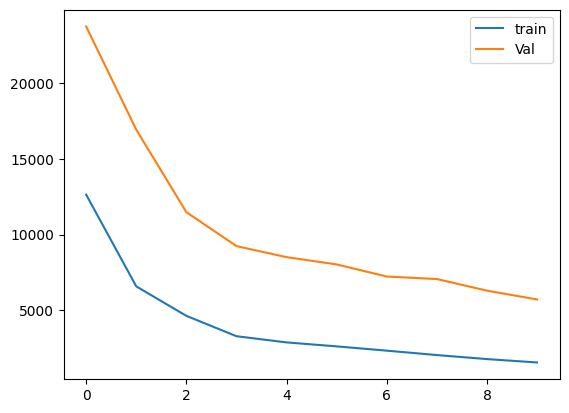

In [ ]:
# plot history for Hours Data
plt.plot(history_hours.history['loss'], label='train')
plt.plot(history_hours.history['val_loss'], label='Val')
plt.legend()
plt.show()

## Keras Tuner

* Hyperparameter Tuning using Hyperband:

In [ ]:
# Model Building With Hyper Paramters Tunning For Days Dataset
model_days, history_days, best_params_days = tune_and_train_model(xd_trn_arr, yd_train, project_name='Days_Model_Tunning', max_epochs=50, fit_epochs=150, patience=10)
best_params_days

Trial 66 Complete [00h 00m 15s]
val_mse: 419097.71875

Best val_mse So Far: 192278.703125
Total elapsed time: 00h 08m 15s
Epoch 1/150
15/15 - 2s - 113ms/step - loss: 8584392.0000 - mse: 8584392.0000 - val_loss: 6938124.0000 - val_mse: 6938124.0000
Epoch 2/150
15/15 - 0s - 8ms/step - loss: 5211937.0000 - mse: 5211937.0000 - val_loss: 1608526.5000 - val_mse: 1608526.5000
Epoch 3/150
15/15 - 0s - 7ms/step - loss: 1462953.2500 - mse: 1462953.2500 - val_loss: 1012770.8125 - val_mse: 1012770.8125
Epoch 4/150
15/15 - 0s - 9ms/step - loss: 948128.4375 - mse: 948128.4375 - val_loss: 700159.7500 - val_mse: 700159.7500
Epoch 5/150
15/15 - 0s - 7ms/step - loss: 665889.3125 - mse: 665889.3125 - val_loss: 448608.3438 - val_mse: 448608.3438
Epoch 6/150
15/15 - 0s - 7ms/step - loss: 518922.7812 - mse: 518922.7812 - val_loss: 351966.1562 - val_mse: 351966.1562
Epoch 7/150
15/15 - 0s - 9ms/step - loss: 465172.7812 - mse: 465172.7812 - val_loss: 312556.0625 - val_mse: 312556.0625
Epoch 8/150
15/15 - 0s -

{'activation': 'relu',
 'initializer': 'he_normal',
 'optimizer': 'adam',
 'lr': 0.006013846979888529,
 'units_1': 192,
 'units_2': 96,
 'units_3': 32,
 'tuner/epochs': 50,
 'tuner/initial_epoch': 17,
 'tuner/bracket': 1,
 'tuner/round': 1,
 'tuner/trial_id': '0052'}

In [ ]:
# Evaluate Days Dataset Model after Tunning
metrics = evaluate_model(model_days, xd_trn_arr, yd_train)

print(f"Model Evaluation Days Data:")
print(f"Loss (MSE): {metrics['loss']:.2f}")
print(f"MSE: {metrics['mse']:.2f}")
print(f"R² Score: {metrics['r2_score']:.2f}")

Model Evaluation Days Data:
Loss (MSE): 185871.50
MSE: 185871.50
R² Score: 0.84


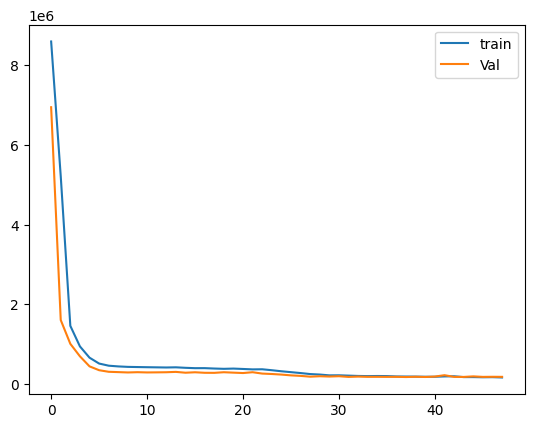

In [ ]:
# plot history for Days Data
plt.plot(history_days.history['loss'], label='train')
plt.plot(history_days.history['val_loss'], label='Val')
plt.legend()
plt.show()

In [ ]:
# Model Building With Hyper Paramters Tunning For Hours Dataset
model_hours, history_hours, best_params_hours = tune_and_train_model(xh_trn_arr, yh_train, project_name='Hours_Model_Tunning', max_epochs=40)
best_params_hours

Trial 72 Complete [00h 00m 24s]
val_mse: 3319.364013671875

Best val_mse So Far: 2193.254638671875
Total elapsed time: 00h 15m 08s
Epoch 1/50
348/348 - 3s - 9ms/step - loss: 1967.8896 - mse: 1967.8896 - val_loss: 3329.8213 - val_mse: 3329.8213
Epoch 2/50
348/348 - 1s - 2ms/step - loss: 719.9664 - mse: 719.9664 - val_loss: 4006.5535 - val_mse: 4006.5535
Epoch 3/50
348/348 - 2s - 5ms/step - loss: 646.0100 - mse: 646.0100 - val_loss: 3729.4866 - val_mse: 3729.4866
Epoch 4/50
348/348 - 2s - 6ms/step - loss: 600.8426 - mse: 600.8426 - val_loss: 3391.5825 - val_mse: 3391.5825
Epoch 5/50
348/348 - 1s - 2ms/step - loss: 567.0665 - mse: 567.0665 - val_loss: 2670.5225 - val_mse: 2670.5225
Epoch 6/50
348/348 - 1s - 4ms/step - loss: 539.5468 - mse: 539.5468 - val_loss: 3300.4846 - val_mse: 3300.4846
Epoch 7/50
348/348 - 1s - 3ms/step - loss: 519.7152 - mse: 519.7152 - val_loss: 2717.4670 - val_mse: 2717.4670
Epoch 8/50
348/348 - 1s - 3ms/step - loss: 512.8906 - mse: 512.8906 - val_loss: 2457.6584 

{'activation': 'relu',
 'initializer': 'he_normal',
 'optimizer': 'nadam',
 'lr': 0.007883698844483387,
 'units_1': 128,
 'units_2': 128,
 'units_3': 16,
 'tuner/epochs': 14,
 'tuner/initial_epoch': 5,
 'tuner/bracket': 2,
 'tuner/round': 1,
 'tuner/trial_id': '0047'}

In [ ]:
# Evaluate Hours Dataset Model after Tunning
metrics = evaluate_model(model_hours, xh_trn_arr, yh_train)

print(f"Model Evaluation Hours Data:")
print(f"Loss (MSE): {metrics['loss']:.2f}")
print(f"MSE: {metrics['mse']:.2f}")
print(f"R² Score: {metrics['r2_score']:.2f}")

Model Evaluation Hours Data:
Loss (MSE): 854.06
MSE: 854.06
R² Score: 0.89


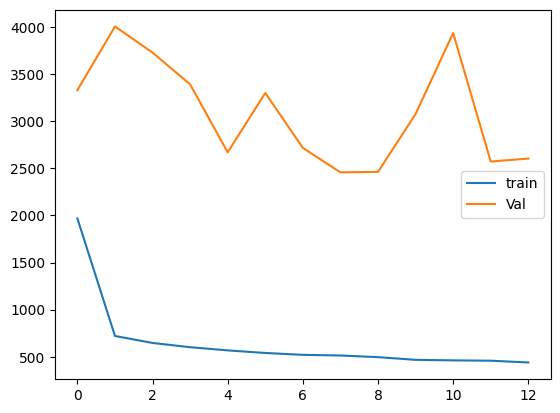

In [ ]:
# plot history for Hours Data
plt.plot(history_hours.history['loss'], label='train')
plt.plot(history_hours.history['val_loss'], label='Val')
plt.legend()
plt.show()

* While validation loss shows oscillations (potential overfitting), the model achieves consistent performance on test data (89% train / 86% test accuracy), indicating good generalization. Further regularization may stabilize training but isn't critically needed given current test results

## DL Conclusion
```
- Best Acc We got With Keras Model For Days Dataset : 81%
- Best Acc We got With Keras Model For Hours Dataset : 89%
```
* If we try a higher number of epochs, we will get better fitting on this data,
but this will take a long time in tuning. So let's try it later.

# ML vs DL

Now We will comapre and Evaluate Best Ml model & Best Dl model on The Test Data

**Days Dataset**

In [ ]:
# Evaluation the Best Ml Model for Days Dataset
model_evaluation(final_xgb_d, xd_test, yd_test,5 , 'Days')

R^2 Score (mean) for Days: 0.76
R^2 Score (std) for Days: 0.05
Accuracy for Days: 0.87 %
RMSE for Days: 404.77


In [ ]:
# Evaluate Keras Model for Days Dataset
metrics = evaluate_model(model_days, xd_tst_arr, yd_test)

print(f"Model Evaluation Days Data:")
print(f"Loss (MSE): {metrics['loss']:.4f}")
print(f"MSE: {metrics['mse']:.4f}")
print(f"R² Score: {metrics['r2_score']:.2f} %")

Model Evaluation Days Data:
Loss (MSE): 234750.4219
MSE: 234750.4219
R² Score: 0.81 %


--------------

**Hours Dataset**

In [ ]:
# Evaluation the Best Ml Model for Hours Dataset
model_evaluation(final_xgb_h, xh_test, yh_test,5 , 'Hours')

R^2 Score (mean) for Hours: 0.69
R^2 Score (std) for Hours: 0.23
Accuracy for Hours: 0.87 %
RMSE for Hours: 48.29


In [ ]:
# Evaluate Keras Model for Hours Dataset
metrics = evaluate_model(model_hours, xh_tst_arr, yh_test)

print(f"Model Evaluation Days Data:")
print(f"Loss (MSE): {metrics['loss']:.4f}")
print(f"MSE: {metrics['mse']:.4f}")
print(f"R² Score: {metrics['r2_score']:.2f} %")

Model Evaluation Days Data:
Loss (MSE): 2367.7883
MSE: 2367.7883
R² Score: 0.86 %


# Final Conclusion
```
- As we can see, the ML model has better fitting on this data than the DL model on Days Data and the same on Hours Data
- As mentioned earlier, deep learning is not typically used with tabular/structured data especially with small Datasets
- It can Use but with very Large Datasets
- However, the goal of this project was
1.Taking a trip with analysis
2.Build A Daily Prediction Model for Days data
3.Build A Hourly Forecasting Model for Hours Data
4.Comparison Between ML VS DL

```